In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [32]:
df= pd.read_csv('/content/housing.csv')

In [33]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [35]:
#total_bedrooms tem dados nulos(207)dados
# 1. Encontra a mediana da coluna total_bedrooms
mediana_quartos = df["total_bedrooms"].median()

# 2. Preenche os valores nulos com essa mediana
df["total_bedrooms"].fillna(mediana_quartos, inplace=True)

/tmp/ipykernel_8350/3763036643.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(mediana_quartos, inplace=True)


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [37]:
#verificando a coluna do object

In [38]:
df['ocean_proximity']

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [39]:
# Transforma a coluna categórica em múltiplas colunas numéricas (0 e 1)
df = pd.get_dummies(df, columns=["ocean_proximity"], dtype=int)

In [40]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0,1,0,0,0


In [41]:
# X recebe tudo, menos a coluna de preço
X = df.drop(columns=["median_house_value"])

# y recebe apenas a coluna de preço
y = df["median_house_value"]

In [42]:
#dividindo os treinos aleatorios

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:

# 1. Cria o modelo
modelo = LinearRegression()

# 2. Treina o modelo com os dados de treino (X_train e y_train)
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [44]:


previsoes = modelo.predict(X_test)

# 2. Calcula o RMSE
rmse = np.sqrt(mean_squared_error(y_test, previsoes))

# 3. Calcula o R² Score
r2 = r2_score(y_test, previsoes)

print(f"Erro Médio (RMSE): US$ {rmse:.2f}")
print(f"Pontuação do Modelo (R²): {r2:.4f}")

Erro Médio (RMSE): US$ 70060.52
Pontuação do Modelo (R²): 0.6254


In [45]:

# 1. Cria o modelo (definindo 100 árvores de decisão para trabalhar em conjunto)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Treina o modelo (esta etapa pode demorar alguns segundos a mais que a anterior)
modelo_rf.fit(X_train, y_train)

# 3. Faz as novas previsões
previsoes_rf = modelo_rf.predict(X_test)

# 4. Avalia os novos resultados
rmse_rf = np.sqrt(mean_squared_error(y_test, previsoes_rf))
r2_rf = r2_score(y_test, previsoes_rf)

print(f"Novo Erro Médio (RMSE): US$ {rmse_rf:.2f}")
print(f"Nova Pontuação do Modelo (R²): {r2_rf:.4f}")


Novo Erro Médio (RMSE): US$ 48977.75
Nova Pontuação do Modelo (R²): 0.8169


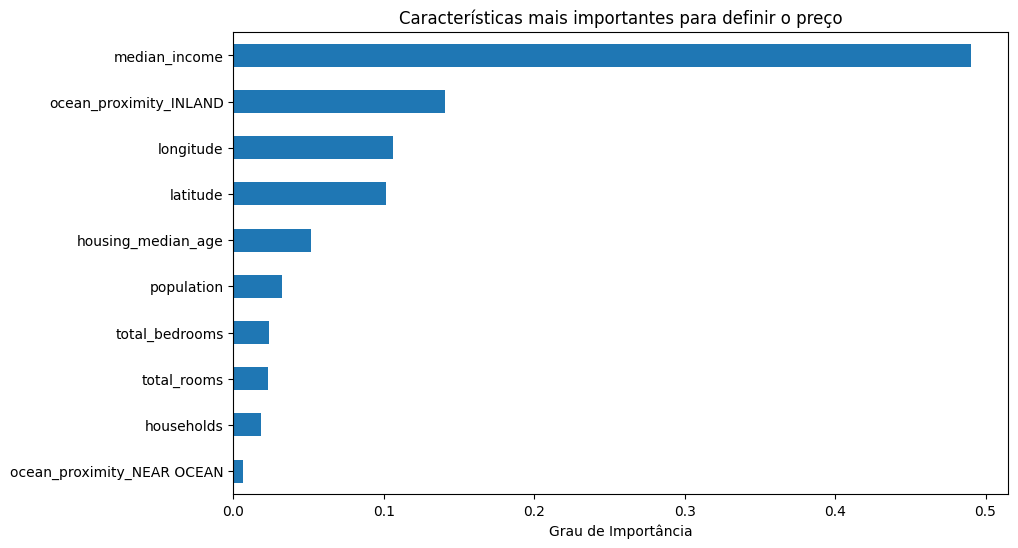

In [46]:

# 1. Pega as importâncias do modelo e associa aos nomes das colunas
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)

# 2. Ordena do maior para o menor e plota um gráfico
importancias.nlargest(10).sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Características mais importantes para definir o preço")
plt.xlabel("Grau de Importância")
plt.show()


In [47]:

# Salva o modelo do Random Forest em um arquivo
joblib.dump(modelo_rf, 'modelo_previsao_casas.pkl')
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [48]:

# 1. Carrega o modelo de volta para a memória
modelo_carregado = joblib.load('modelo_previsao_casas.pkl')

# 2. Simula os dados de um novo distrito (exemplo rápido usando uma linha do seu X_test)
nova_casa = X_test.iloc[[0]]
preco_real = y_test.iloc[0]

# 3. O modelo faz a previsão
previsao_sistema = modelo_carregado.predict(nova_casa)

print(f"Preço Real no Censo: US$ {preco_real:.2f}")
print(f"Previsão do seu Sistema: US$ {previsao_sistema[0]:.2f}")

Preço Real no Censo: US$ 47700.00
Previsão do seu Sistema: US$ 51744.00
